<a href="https://colab.research.google.com/github/pavansrisai45-afk/canny-edge-detection/blob/main/cannyedgedetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving wolf.jpg to wolf (2).jpg


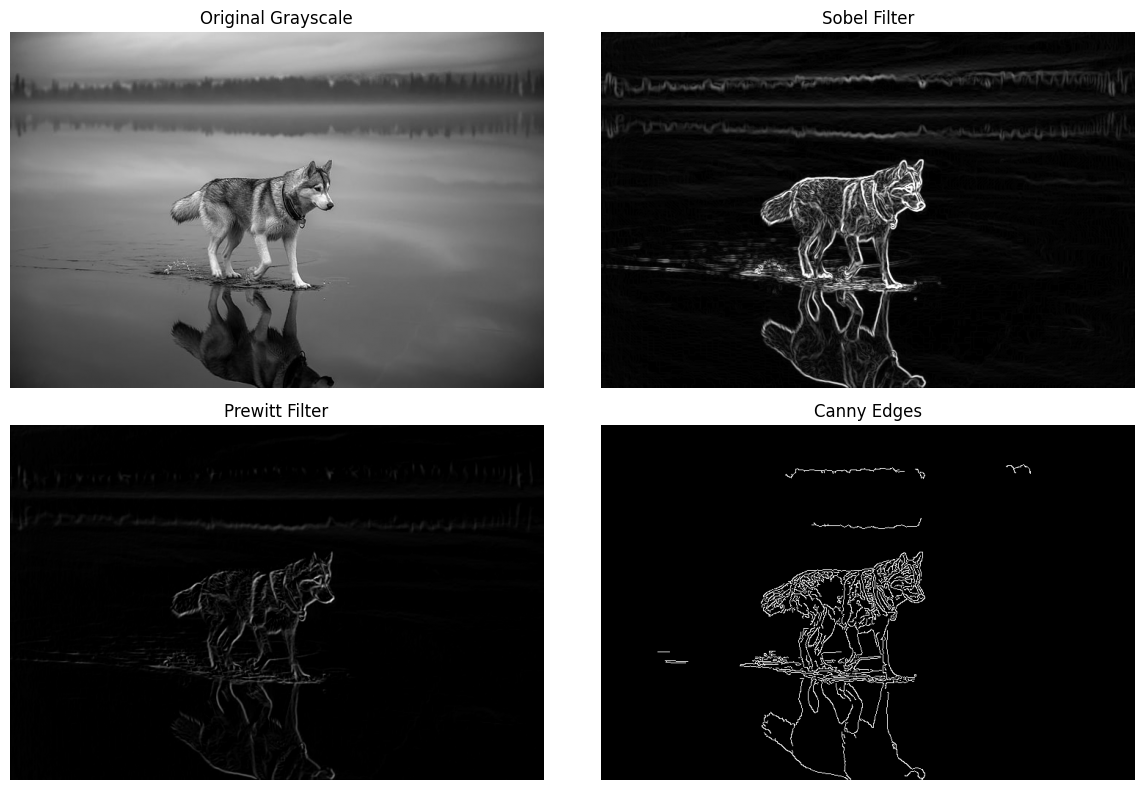

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# 1. Upload your image directly into Colab
uploaded = files.upload()
image_name = list(uploaded.keys())[0]

# 2. Read the uploaded image and convert to grayscale
image = cv2.imread(image_name)
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply Gaussian blur to reduce noise (Smoothing step)
blurred_image = cv2.GaussianBlur(gray_image, (3, 3), 0)

# --- 3. Sobel Edge Detection ---
sobel_x = cv2.Sobel(blurred_image, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(blurred_image, cv2.CV_64F, 0, 1, ksize=3)
sobel_combined = cv2.magnitude(sobel_x, sobel_y)
sobel_combined = np.uint8(np.clip(sobel_combined, 0, 255))

# --- 4. Prewitt Edge Detection ---
kernel_prewitt_x = np.array([[-1, 0, 1],
                             [-1, 0, 1],
                             [-1, 0, 1]], dtype=np.float32)

kernel_prewitt_y = np.array([[-1, -1, -1],
                             [ 0,  0,  0],
                             [ 1,  1,  1]], dtype=np.float32)

prewitt_x = cv2.filter2D(blurred_image, -1, kernel_prewitt_x)
prewitt_y = cv2.filter2D(blurred_image, -1, kernel_prewitt_y)
prewitt_combined = cv2.addWeighted(prewitt_x, 0.5, prewitt_y, 0.5, 0)

# --- 5. Canny Edge Detection ---
canny_edges = cv2.Canny(blurred_image, threshold1=50, threshold2=150)

# --- 6. Plot & Display Results ---
titles = ['Original Grayscale', 'Sobel Filter', 'Prewitt Filter', 'Canny Edges']
images = [gray_image, sobel_combined, prewitt_combined, canny_edges]

plt.figure(figsize=(12, 8))
for i in range(4):
    plt.subplot(2, 2, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()